# Fidélité des volumes FreeSurfer après traitement

Dans `aseg.stats`, FreeSurfer donne un volume en mm³ pour chaque structure. Par exemple : hippocampe, ventricule ou putamen. Ce n'est pas le volume du fichier IRM entier.

La référence est toujours `brut/run-01` du même sujet. C'est le scan presque immobile, traité par FreeSurfer à partir de l'image brute.

On compare cette référence avec :

- `preproc/run-01`, `JDAC/run-01` et les variantes sur le scan presque immobile ;
- les mêmes conditions sur `run-02` et `run-03`, qui sont les scans bougés.

Ce notebook pose deux questions :

1. Les traitements changent-ils les volumes sur `run-01` ?
2. Sur les scans bougés, JDAC fait-il mieux que preproc ?

Le calcul est fait sujet par sujet. Chaque sujet donne une valeur par condition. C'est cette valeur qui est comparée entre conditions.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown
warnings.filterwarnings("ignore")

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
LABELS = {
    "brut": "brut", "preproc": "preproc", "jdac": "JDAC",
    "jdac_antiartonly": "antiart ×1", "jdac_nodenoise": "antiart ×4",
}
ASEG_DIR = Path.home() / "Documents/derivatives/ds004332/aseg_stats"
ASEG_FILES = {
    "brut": "aseg_brut.csv",
    "preproc": "aseg_preproc.csv",
    "jdac": "aseg_jdac.csv",
    "jdac_antiartonly": "aseg_antiartonly.csv",
    "jdac_nodenoise": "aseg_nodenoise.csv",
}

# Lit une table aseg (format large : une ligne par acquisition, une colonne par
# structure) et la retourne en format long (une ligne par structure), avec les
# colonnes subject, run, measure, value_mm3, condition.
def load_table(condition, filename):
    wide = pd.read_csv(ASEG_DIR / filename, sep="	")
    id_col = "Measure:volume" if "Measure:volume" in wide.columns else wide.columns[0]
    # Sépare l'identifiant "sub-XX_run-YY" en sujet et run.
    ids = wide[id_col].astype(str).str.extract(r"(sub-[^_/\s]+)_(run-\d+)", expand=True)
    if ids.isna().any().any():
        raise ValueError(f"Identifiants non reconnus dans {filename}")
    return (wide.drop(columns=id_col)
            .assign(subject=ids[0].values, run=ids[1].values)
            .melt(id_vars=["subject", "run"], var_name="measure", value_name="value_mm3")
            .assign(condition=condition))

missing = [name for name in ASEG_FILES.values() if not (ASEG_DIR / name).is_file()]
if missing:
    raise FileNotFoundError("Tables absentes : " + ", ".join(missing))

# Empile les 5 conditions dans un seul tableau long d.
d = pd.concat([load_table(c, f) for c, f in ASEG_FILES.items()], ignore_index=True)
d["value_mm3"] = pd.to_numeric(d["value_mm3"], errors="coerce")
d["condition"] = pd.Categorical(d["condition"], CONDITIONS, ordered=True)

# Score de mouvement Agitation (covariable de la question 3), joint par sujet et run.
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "results/ds004332").exists()), Path.home() / "Documents/GitHub/jdac-motion-correction")
AGIT = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"
agit = pd.read_csv(AGIT).rename(columns={"sub":"subject", "condition":"run", "motion":"agitation"})
d = d.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="left")

# GLOBAL : six grands compartiments tissulaires, utilisés seulement par le
# tableau descriptif (sens de l'effet), jamais par le score principal.
GLOBAL = [
    "CortexVol", "TotalGrayVol", "CerebralWhiteMatterVol",
    "SubCortGrayVol", "CSF", "BrainSegVolNotVent",
]
GLOBAL_LABELS = {
    "CortexVol": "Substance grise corticale (CortexVol)",
    "TotalGrayVol": "Substance grise totale (TotalGrayVol)",
    "CerebralWhiteMatterVol": "Substance blanche cérébrale (CerebralWhiteMatterVol)",
    "SubCortGrayVol": "Substance grise sous-corticale (SubCortGrayVol)",
    "CSF": "LCR segmenté (CSF)",
    "BrainSegVolNotVent": "Cerveau segmenté hors ventricules (BrainSegVolNotVent)",
}
# EXCLUDED : mesures non anatomiques (ratios -to-eTIV, trous de surface,
# hypointensités). Base quasi nulle, un pourcentage n'y a pas de sens : écartées.
EXCLUDED = {
    "EstimatedTotalIntraCranialVol", "SegmentedTotalIntracranialVol",
    "BrainSegVol-to-eTIV", "MaskVol-to-eTIV",
    "SurfaceHoles", "lhSurfaceHoles", "rhSurfaceHoles",
    "WM-hypointensities", "Left-WM-hypointensities",
    "Right-WM-hypointensities", "non-WM-hypointensities",
    "Left-non-WM-hypointensities", "Right-non-WM-hypointensities",
}
base_median = (d[(d.condition=="brut") & (d.run=="run-01")]
               .groupby("measure", observed=True).value_mm3.median())
# Mesures assez grandes pour un pourcentage stable (> 100 mm³).
# On enlève les ratios et les mesures de qualité. Les six volumes du tableau
# descriptif sont calculés séparément.
score_measures = [m for m in base_median.index
                  if m not in EXCLUDED and m not in GLOBAL and base_median[m] > 100]

context = pd.DataFrame([{
    "Sujets": d.subject.nunique(),
    "Runs": d.run.nunique(),
    "Conditions": d.condition.nunique(),
    "Acquisitions disponibles": f"{d[['subject','run','condition']].drop_duplicates().shape[0]}/{d.subject.nunique()*d.run.nunique()*d.condition.nunique()}",
    "Mesures du score": len(score_measures),
}])
display(context)

,Sujets,Runs,Conditions,Acquisitions disponibles,Mesures du score
0,22,3,5,325/330,40


### Mesures utilisées

Le score principal utilise 40 mesures :

- 32 structures prises séparément, par exemple l'hippocampe gauche ou le putamen droit ;
- 8 grands volumes déjà calculés par FreeSurfer, par exemple `BrainSegVol`, les volumes de cortex et de substance blanche de chaque hémisphère, `SupraTentorialVol` et `MaskVol`.

Pour chaque mesure, on calcule l'écart en % par rapport à `brut/run-01`. Puis on prend la médiane des 40 écarts. Chaque mesure compte donc autant dans le score.

On enlève les structures de moins de 100 mm³, les ratios et les mesures de qualité. Leur pourcentage serait difficile à interpréter ici.

Le tableau suivant utilise seulement six grands volumes : grise corticale, grise totale, blanche cérébrale, grise sous-corticale, LCR et cerveau hors ventricules. Il sert juste à voir quel type de tissu augmente ou diminue. Il ne sert pas au test principal.

Les volumes de départ sont en **mm³**. Les tableaux montrent des **% par rapport à brut/run-01**.

## 1. Le traitement modifie-t-il le scan presque immobile ?

Pour un sujet et une mesure donnée, la référence **R** = volume FreeSurfer du **brut/run-01**. Le volume comparé **T** est la sortie de la condition correspondante sur le **même run-01** : par exemple, `preproc/run-01`, `JDAC/run-01`, `antiart ×1/run-01` ou `antiart ×4/run-01`.

On calcule d'abord, structure par structure :

**erreur absolue (%) = |T − R| / R × 100**

Puis on prend la médiane des mesures du score pour ce sujet. Cette **erreur d'identité** répond seulement à « de combien le résultat s'éloigne-t-il du brut/run-01 ? » : elle est toujours positive ou nulle et ne dit donc pas si une structure grossit ou s'amincit. Une valeur faible est meilleure. La conclusion est **sous** le boxplot.

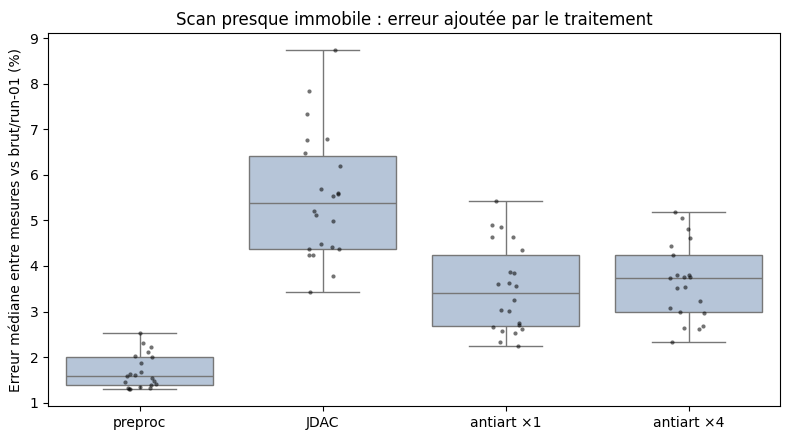

**Conclusion.** Sur un scan immobile il n'y a rien à corriger, donc tout écart au brut est une déformation ajoutée par le traitement. Médiane de l'erreur vs brut : preproc 1.6 %, JDAC 5.4 %, antiart ×1 3.4 %, antiart ×4 3.7 %. **preproc reste le plus proche du brut, JDAC s'en éloigne le plus.** JDAC modifie donc un cerveau propre au lieu de le laisser presque tel quel.

In [2]:
# Étape 1 : fixer, pour chaque sujet et chaque mesure, la référence R = brut/run-01.
ref = (d[(d.condition=="brut") & (d.run=="run-01") & d.measure.isin(score_measures)]
       [["subject","measure","value_mm3"]]
       .rename(columns={"value_mm3":"reference_mm3"}))

# Étape 2 : associer chaque sortie run-01 à R du même sujet.
still = (d[(d.run=="run-01") & d.measure.isin(score_measures)]
         .merge(ref, on=["subject","measure"], how="inner"))
# Étape 3 : prendre la valeur absolue. L'erreur est une distance à R.
still["error_pct"] = 100 * (still.value_mm3-still.reference_mm3).abs() / still.reference_mm3
# Étape 4 : prendre la médiane des mesures pour chaque sujet et condition.
identity = (still.groupby(["subject","condition"], observed=True).error_pct
            .median().reset_index(name="erreur_identite_pct"))

plt.figure(figsize=(8,4.5))
sns.boxplot(data=identity[identity.condition!="brut"], x="condition",
            y="erreur_identite_pct", order=CONDITIONS[1:], color="lightsteelblue")
sns.stripplot(data=identity[identity.condition!="brut"], x="condition",
              y="erreur_identite_pct", order=CONDITIONS[1:],
              color="black", alpha=.55, size=3)
plt.xticks(range(4), [LABELS[c] for c in CONDITIONS[1:]])
plt.ylabel("Erreur médiane entre mesures vs brut/run-01 (%)")
plt.xlabel("")
plt.title("Scan presque immobile : erreur ajoutée par le traitement")
plt.tight_layout()
plt.show()

# Conclusion calculée : médiane de l'erreur vs brut, par condition (chaque point du boxplot = un sujet).
med = identity.groupby("condition", observed=True).erreur_identite_pct.median()
cand = med.drop("brut")
best, worst = LABELS[cand.idxmin()], LABELS[cand.idxmax()]
display(Markdown(
    "**Conclusion.** Sur un scan immobile il n'y a rien à corriger, donc tout écart au brut est une déformation "
    "ajoutée par le traitement. Médiane de l'erreur vs brut : "
    f"preproc {med['preproc']:.1f} %, JDAC {med['jdac']:.1f} %, "
    f"antiart ×1 {med['jdac_antiartonly']:.1f} %, antiart ×4 {med['jdac_nodenoise']:.1f} %. "
    f"**{best} reste le plus proche du brut, {worst} s'en éloigne le plus.** "
    "JDAC modifie donc un cerveau propre au lieu de le laisser presque tel quel."))

### Où se produit le changement ?

**À quoi ça sert :** la question 1 dit *de combien* JDAC s'écarte du brut, pas *dans quel sens*. Ce tableau montre la **direction** du changement, pour comprendre le mécanisme.

**Ce qui est calculé :** pour chaque grand compartiment et chaque sujet, la variation par rapport à son brut/run-01, `(volume traité − volume brut) / volume brut × 100`, puis la médiane sur les sujets. **Unité : %.** Le signe est gardé : négatif = le compartiment a rétréci, positif = il a grossi.

**Pourquoi ces 6 zones :** ce sont les grands tissus du cerveau (matière grise, blanche, LCR, cerveau total). Un lissage se lit comme du gris qui bascule en blanc et en LCR ; ces 6 compartiments suffisent à voir ce basculement, sans se noyer dans les 40 structures détaillées.

| Nom FreeSurfer | En clair | Contenu |
|---|---|---|
| `CortexVol` | Substance grise corticale | somme des cortex gauche et droit |
| `TotalGrayVol` | Substance grise totale | grise corticale + sous-corticale + cervelet |
| `CerebralWhiteMatterVol` | Substance blanche cérébrale | blanche des deux hémisphères |
| `SubCortGrayVol` | Substance grise sous-corticale | noyaux gris profonds |
| `CSF` | LCR segmenté | voxels classés liquide cérébrospinal par aseg |
| `BrainSegVolNotVent` | Cerveau hors ventricules | cerveau segmenté, ventricules retirés |

L'interprétation des chiffres suit **sous** le tableau.

In [3]:
# Variation (%) de chaque compartiment sur run-01 vs brut/run-01, médiane sur les sujets.
# On garde le sens : - = plus petit qu'au brut, + = plus grand.
gref = (d[(d.condition=="brut") & (d.run=="run-01") & d.measure.isin(GLOBAL)]
        [["subject","measure","value_mm3"]]
        .rename(columns={"value_mm3":"reference_mm3"}))
g = (d[(d.run=="run-01") & d.measure.isin(GLOBAL) & (d.condition!="brut")]
     .merge(gref, on=["subject","measure"], how="inner"))
g["signed_pct"] = 100 * (g.value_mm3-g.reference_mm3) / g.reference_mm3
# Table médiane : lignes = conditions, colonnes = compartiments (noms FreeSurfer d'origine).
gt = (g.groupby(["condition","measure"], observed=True).signed_pct
      .median().unstack("measure").reindex(CONDITIONS[1:])[GLOBAL])
disp = gt.copy()
disp.columns = [GLOBAL_LABELS[c] for c in disp.columns]
disp.index = [LABELS[c] for c in disp.index]
# Le + ou - dans chaque case indique le sens du changement.
display(disp.style.format("{:+.1f} %").set_caption("Variation vs brut/run-01 (%)"))

# Interprétation calculée (gt garde les noms d'origine).
j = gt.loc["jdac"]
prep_absmax = gt.loc["preproc"].abs().max()
display(Markdown(
    "**Ce qu'on apprend.** Le changement a un sens précis, ce n'est pas du bruit. "
    f"Sur run-01, JDAC réduit la substance grise corticale (**{j['CortexVol']:+.0f} %**) et augmente la "
    f"substance blanche (**{j['CerebralWhiteMatterVol']:+.0f} %**) et le LCR (**{j['CSF']:+.0f} %**) : "
    "de la matière classée « grise » sur le brut passe en « blanche » ou en « LCR » après JDAC. "
    "C'est la signature d'un lissage des frontières gris/blanc, pas d'une correction du mouvement. "
    f"En comparaison, preproc reste sous ±{prep_absmax:.0f} % sur tous les compartiments."))

,Substance grise corticale (CortexVol),Substance grise totale (TotalGrayVol),Substance blanche cérébrale (CerebralWhiteMatterVol),Substance grise sous-corticale (SubCortGrayVol),LCR segmenté (CSF),Cerveau segmenté hors ventricules (BrainSegVolNotVent)
preproc,-4.1 %,-2.4 %,-0.2 %,-0.6 %,+3.0 %,-1.0 %
JDAC,-14.3 %,-11.2 %,+10.7 %,-2.5 %,+9.9 %,-3.0 %
antiart ×1,-8.2 %,-5.9 %,+3.2 %,-2.4 %,+3.1 %,-1.8 %
antiart ×4,-1.2 %,-2.0 %,-1.5 %,-6.1 %,+5.1 %,-1.5 %


**Ce qu'on apprend.** Le changement a un sens précis, ce n'est pas du bruit. Sur run-01, JDAC réduit la substance grise corticale (**-14 %**) et augmente la substance blanche (**+11 %**) et le LCR (**+10 %**) : de la matière classée « grise » sur le brut passe en « blanche » ou en « LCR » après JDAC. C'est la signature d'un lissage des frontières gris/blanc, pas d'une correction du mouvement. En comparaison, preproc reste sous ±4 % sur tous les compartiments.

## 2. Sur les scans bougés, JDAC récupère-t-il les volumes ?

Même calcul que la question 1, mais sur les runs qui ont **bougé** (`run-02` léger, `run-03` fort). On mesure toujours l'écart au **brut/run-01** du même sujet.

Le boxplot montre, pour chaque condition, la distance des volumes au brut immobile : une boîte plus basse = plus fidèle. Les 5 conditions sont affichées, **y compris le brut bougé** (le scan qui a bougé, sans aucune correction), pour voir si corriger aide vraiment. La conclusion est **sous** la figure.

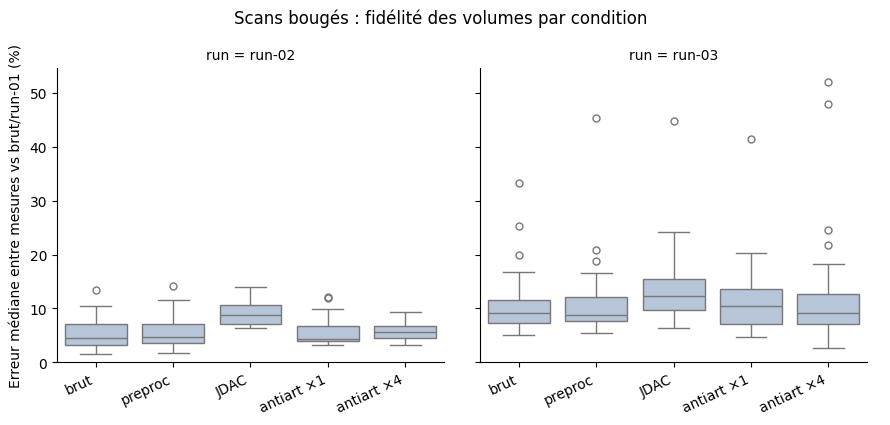

**Conclusion.** Sur un scan bougé, corriger devrait *rapprocher* les volumes du brut immobile. Médiane de l'erreur vs brut :

- run-02 : brut 4.6 %, preproc 4.7 %, JDAC 8.8 %, antiart ×1 4.4 %, antiart ×4 5.6 %
- run-03 : brut 9.2 %, preproc 8.8 %, JDAC 12.4 %, antiart ×1 10.5 %, antiart ×4 9.1 %

La condition **la plus éloignée** du brut est **JDAC** (run-02) et **JDAC** (run-03) : JDAC n'aide pas à récupérer les volumes, il fait même pire que le brut non corrigé.

In [4]:
# Étape 1 : associer les sorties des runs bougés à R = brut/run-01.
moved = (d[d.run.isin(["run-02","run-03"]) & d.measure.isin(score_measures)]
         .merge(ref, on=["subject","measure"], how="inner"))
# Étape 2 : même erreur absolue, puis médiane des mesures pour chaque sujet.
moved["error_pct"] = 100 * (moved.value_mm3-moved.reference_mm3).abs() / moved.reference_mm3
fidelity = (moved.groupby(["subject","run","condition"], observed=True).error_pct
            .median().reset_index(name="erreur_regionale_pct"))

gplot = sns.catplot(data=fidelity, x="condition", y="erreur_regionale_pct",
                    col="run", kind="box", order=CONDITIONS,
                    color="lightsteelblue", height=4.2, aspect=1.05)
for ax in gplot.axes.flat:
    ax.set_xticks(range(5))
    ax.set_xticklabels([LABELS[c] for c in CONDITIONS], rotation=25, ha="right")
    ax.set_xlabel("")
    ax.set_ylabel("Erreur médiane entre mesures vs brut/run-01 (%)")
    ax.set_ylim(bottom=0)  # erreur absolue : 0 est la fidélité parfaite à la référence
gplot.fig.subplots_adjust(top=.84)
gplot.fig.suptitle("Scans bougés : fidélité des volumes par condition")
plt.show()

# Conclusion calculée : médiane de l'erreur vs brut, par condition et par run.
med = (fidelity.groupby(["run","condition"], observed=True).erreur_regionale_pct
       .median().unstack("condition"))
worst02, worst03 = LABELS[med.loc["run-02"].idxmax()], LABELS[med.loc["run-03"].idxmax()]
def _ligne(run):
    m = med.loc[run]
    return (f"{run} : brut {m['brut']:.1f} %, preproc {m['preproc']:.1f} %, JDAC {m['jdac']:.1f} %, "
            f"antiart ×1 {m['jdac_antiartonly']:.1f} %, antiart ×4 {m['jdac_nodenoise']:.1f} %")
display(Markdown(
    "**Conclusion.** Sur un scan bougé, corriger devrait *rapprocher* les volumes du brut immobile. "
    "Médiane de l'erreur vs brut :\n\n"
    f"- {_ligne('run-02')}\n"
    f"- {_ligne('run-03')}\n\n"
    f"La condition **la plus éloignée** du brut est **{worst02}** (run-02) et **{worst03}** (run-03) : "
    "JDAC n'aide pas à récupérer les volumes, il fait même pire que le brut non corrigé."))

## 3. Après correction, le mouvement explique-t-il encore les volumes ?

**L'idée simple.** Quand un scan bouge, ses volumes sont faussés. Si la correction marchait, après traitement le mouvement ne devrait plus rien expliquer. On regarde donc, par condition, **combien de volumes (sur 40) sont encore influencés par le mouvement**.

**Comment on le sait.** Pour chaque volume, on teste s'il change quand le score de mouvement du scan augmente (score « Agitation », 0 = immobile, environ 3 = fort). Point technique : chaque sujet a une tête d'une taille différente, donc on regarde l'effet du mouvement **à l'intérieur d'un même sujet** (chacun garde son niveau de base), sinon on confondrait « bouge beaucoup » avec « a un gros cerveau ».

**À lire dans le tableau :** le nombre de volumes encore liés au mouvement, par condition. **Moins qu'au brut = la correction aide ; plus = elle n'aide pas.**

In [5]:
rows = []
for condition in CONDITIONS:
    dc = d[(d.condition==condition) & d.measure.isin(score_measures)].dropna(subset=["agitation","value_mm3"])
    for measure, x in dc.groupby("measure", observed=True):
        if len(x) < 20 or x.subject.nunique() < 8:   # trop peu de données pour modéliser
            continue
        try:
            fit = smf.mixedlm("value_mm3 ~ agitation", x, groups=x.subject).fit(
                reml=False, method="lbfgs", disp=False)
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
        except Exception:
            # repli si le modèle mixte ne converge pas : sujet en effet fixe (pas d'abandon silencieux).
            fit = smf.ols("value_mm3 ~ agitation + C(subject)", x).fit()
            coef, p = fit.params["agitation"], fit.pvalues["agitation"]
        rows.append({"condition":condition, "measure":measure, "coef":coef, "p":p})
agit_c = pd.DataFrame(rows)
# FDR par condition (sur les modèles qui ont convergé).
agit_c["p_fdr"] = np.nan
for cond, grp in agit_c.groupby("condition", observed=True):
    v = grp["p"].notna()
    if v.any():
        agit_c.loc[grp.index[v], "p_fdr"] = multipletests(grp.loc[v, "p"], method="fdr_bh")[1]

cnt = (agit_c.assign(sig=agit_c["p_fdr"] < 0.05).groupby("condition", observed=True)
       .agg(**{"mesures liées à Agitation (FDR<0.05)":("sig","sum"), "mesures testées":("sig","size")}))
cnt.index = [LABELS[c] for c in cnt.index]
display(cnt)

# Interprétation calculée.
sig = agit_c.assign(s=agit_c["p_fdr"] < 0.05).groupby("condition", observed=True)["s"].sum()
nb_brut, nb_prep, nb_jdac = int(sig.get("brut",0)), int(sig.get("preproc",0)), int(sig.get("jdac",0))
sens = "moins" if nb_jdac < nb_brut else ("autant" if nb_jdac == nb_brut else "plus")
lien = ("JDAC ne découple donc pas le volume du mouvement : contrairement à l'épaisseur, où le lien Agitation "
        "diminuait après JDAC, sur les volumes le mouvement reste au moins aussi prédictif."
        if nb_jdac >= nb_brut else
        "JDAC réduit le nombre de volumes liés au mouvement, comme il réduisait le lien sur l'épaisseur.")
display(Markdown(
    f"**Ce qu'on apprend.** Sur le brut, **{nb_brut}** mesures du score sont liées à Agitation (sur {int(cnt['mesures testées'].max())} testées). "
    f"Après preproc il y en a {nb_prep}, après JDAC **{nb_jdac}** : {sens} qu'au brut. "
    + lien +
    " À nuancer par la question 1 : ce (dé)couplage s'accompagne d'un déplacement des volumes du scan immobile."))

,mesures liées à Agitation (FDR<0.05),mesures testées
brut,27,40
JDAC,34,40
antiart ×1,29,40
antiart ×4,34,40
preproc,28,40


**Ce qu'on apprend.** Sur le brut, **27** mesures du score sont liées à Agitation (sur 40 testées). Après preproc il y en a 28, après JDAC **34** : plus qu'au brut. JDAC ne découple donc pas le volume du mouvement : contrairement à l'épaisseur, où le lien Agitation diminuait après JDAC, sur les volumes le mouvement reste au moins aussi prédictif. À nuancer par la question 1 : ce (dé)couplage s'accompagne d'un déplacement des volumes du scan immobile.

## Conclusion : les volumes sont-ils reconstruits aussi fidèlement que l'épaisseur ?

La question n'est pas « JDAC bat-il preproc » en soi. Dans l'article, la validité de JDAC repose sur la **fidélité de l'image**. Le premier notebook a testé si cette fidélité se retrouvait sur l'**épaisseur corticale** FreeSurfer (déplacement du scan immobile, récupération des scans bougés, lien Agitation→épaisseur). Ce notebook pose la même question pour les **volumes**.

Les deux lectures de ce notebook se recoupent avec le premier :

- **Scan immobile :** JDAC déforme les volumes là où il n'y a rien à corriger (grise reclassée en blanche + LCR), comme il déplaçait déjà l'épaisseur du run immobile.
- **Scans bougés :** JDAC ne rapproche pas les volumes du brut/run-01 mieux que preproc, comme il ne restaurait pas l'épaisseur régionale.

Une meilleure image ne suffit donc pas : sur les volumes comme sur l'épaisseur, JDAC modifie l'anatomie du scan propre et n'améliore pas la fidélité des scans bougés.

La **question 3** ferme le lien avec le premier notebook : sur l'épaisseur, JDAC réduisait le lien Agitation→épaisseur (au prix d'un déplacement du scan immobile) ; sur les volumes, elle mesure si ce lien diminue aussi ou non. À lire avec la question 1, car un découplage obtenu en déformant le scan propre n'est pas une reconstruction fidèle.

In [6]:
# Synthèse en langage simple, à partir des médianes d'erreur vs brut (aucun jargon).
id_med = identity.groupby("condition", observed=True).erreur_identite_pct.median()
mv_med = fidelity.groupby(["run","condition"], observed=True).erreur_regionale_pct.median()
sig_cnt = agit_c.assign(s=agit_c["p_fdr"] < 0.05).groupby("condition", observed=True)["s"].sum()

print(f"1. Scan immobile : erreur vs brut de {id_med['preproc']:.1f} % pour preproc contre {id_med['jdac']:.1f} % pour JDAC.")
print("   -> JDAC déforme le plus un cerveau qui n'avait rien à corriger.")
print(f"2. Scans bougés : la condition la plus éloignée du brut est {LABELS[mv_med.loc['run-02'].idxmax()]} (run-02) et {LABELS[mv_med.loc['run-03'].idxmax()]} (run-03).")
print("   -> corriger avec JDAC n'aide pas, il éloigne même les volumes du scan immobile.")
print(f"3. Mouvement : {int(sig_cnt['brut'])} volumes liés au mouvement au brut, {int(sig_cnt['jdac'])} après JDAC.")
print("   -> JDAC ne découple pas le mouvement des volumes (il en laisse même plus).")
print("Bilan : une image plus nette n'est pas une anatomie plus fidèle ; JDAC ne reconstruit pas mieux les volumes que le simple preproc.")

1. Scan immobile : erreur vs brut de 1.6 % pour preproc contre 5.4 % pour JDAC.
   -> JDAC déforme le plus un cerveau qui n'avait rien à corriger.
2. Scans bougés : la condition la plus éloignée du brut est JDAC (run-02) et JDAC (run-03).
   -> corriger avec JDAC n'aide pas, il éloigne même les volumes du scan immobile.
3. Mouvement : 27 volumes liés au mouvement au brut, 34 après JDAC.
   -> JDAC ne découple pas le mouvement des volumes (il en laisse même plus).
Bilan : une image plus nette n'est pas une anatomie plus fidèle ; JDAC ne reconstruit pas mieux les volumes que le simple preproc.
